# BPED - Bio-inspired Pyramid Edge Detection Evaluation

This notebook evaluates the BPED model on test images and computes ODS, OIS, and AP metrics.

In [16]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F
from torchvision import transforms
import cv2
from tqdm.notebook import tqdm

from model import BPED

## 1. Setup

In [17]:
# Configuration
DATASET_PATH = r'..\datasets\HED_Small'
CHECKPOINT_PATH = r'checkpoints\bped_20260216_021108\best_model.pth'  # Update with your checkpoint
IMAGE_SIZE = 320
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"Dataset: {DATASET_PATH}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Device: cuda
Dataset: ..\datasets\HED_Small
Checkpoint: checkpoints\bped_20260216_021108\best_model.pth


## 2. Load Model

In [18]:
# Create model
model = BPED().to(DEVICE)
print(f"Model parameters: {model.count_parameters():,}")

# Load checkpoint if available
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✓ Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
else:
    print("⚠ No checkpoint found, using random weights")

model.eval()

Model parameters: 43,737,129


C:\Users\imed\AppData\Local\Temp\ipykernel_23300\877740625.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


✓ Loaded checkpoint from epoch 2


BPED(
  (encoder): BPEDEncoder(
    (stage1): Sequential(
      (0): OrientedConv(
        (oriented_convs): ModuleList(
          (0-3): 4 x Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): OrientedConv(
        (oriented_convs): ModuleList(
          (0-3): 4 x Conv2d(64, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (2): PyramidBlock(
        (scale1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (scale2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        (scale3): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (fusion): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## 3. Prepare Data

In [19]:
# Get test images
test_dir = os.path.join(DATASET_PATH, 'test', 'images')

# Fallback if images subfolder doesn't exist
if not os.path.exists(test_dir):
    test_dir = os.path.join(DATASET_PATH, 'test')
    if not os.path.exists(test_dir):
        test_dir = DATASET_PATH

image_files = sorted([
    f for f in os.listdir(test_dir)
    if f.endswith(('.jpg', '.png', '.jpeg')) and not f.startswith('.')
])

print(f"Found {len(image_files)} test images")
print(f"Loading from: {test_dir}")

# Image transform
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Found 32 test images
Loading from: ..\datasets\HED_Small\test\images


## 4. Run Inference

In [20]:
results = []

with torch.no_grad():
    for img_file in tqdm(image_files, desc="Processing"):
        # Load image
        img_path = os.path.join(test_dir, img_file)
        image = Image.open(img_path).convert('RGB')
        orig_size = image.size
        
        # Transform
        img_tensor = transform(image).unsqueeze(0).to(DEVICE)
        
        # Predict
        edge_map = model(img_tensor)
        
        # Post-process
        edge_map = edge_map.squeeze().cpu().numpy()
        
        # Resize back to original
        edge_map = cv2.resize(edge_map, orig_size, interpolation=cv2.INTER_LINEAR)
        
        results.append({
            'filename': img_file,
            'edge_map': edge_map,
            'original_image': np.array(image)
        })

print(f"✓ Processed {len(results)} images")

Processing:   0%|          | 0/32 [00:00<?, ?it/s]

✓ Processed 32 images


## 5. Visualize Results

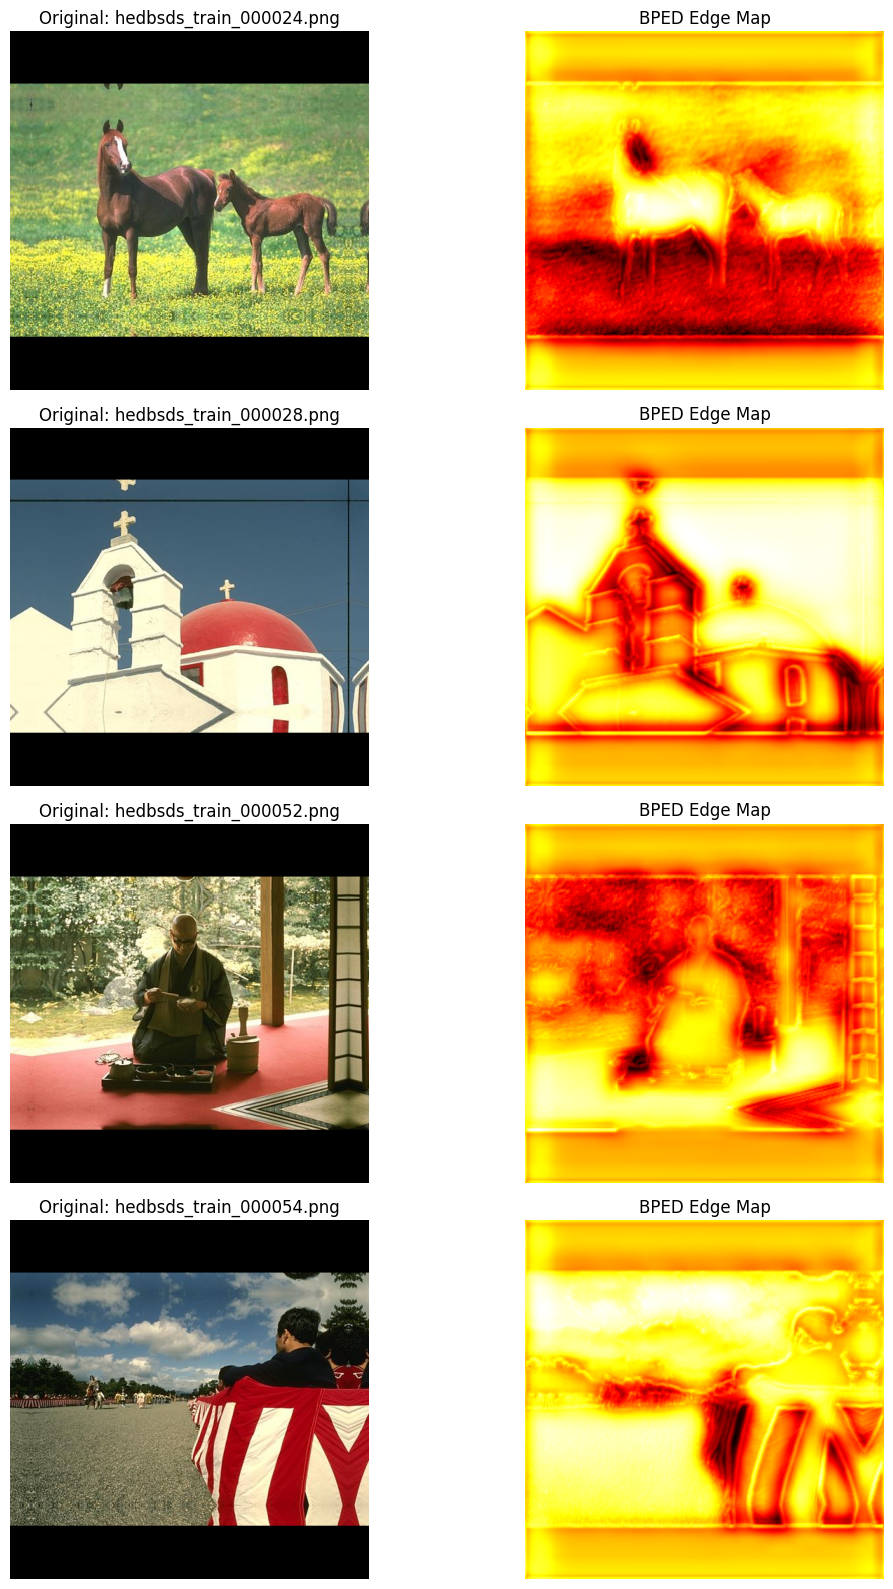

✓ Visualization saved as bped_results.png


In [21]:
# Show first 4 results
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for i in range(min(4, len(results))):
    result = results[i]
    
    # Original image
    axes[i, 0].imshow(result['original_image'])
    axes[i, 0].set_title(f"Original: {result['filename']}")
    axes[i, 0].axis('off')
    
    # Edge map
    axes[i, 1].imshow(result['edge_map'], cmap='hot')
    axes[i, 1].set_title('BPED Edge Map')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('bped_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved as bped_results.png")

## 6. Compute Metrics (ODS, OIS, AP)

Simplified metric computation using thresholds

In [22]:
def compute_metrics(edge_map, gt_edge=None, thresholds=np.linspace(0, 1, 20)):
    """
    Compute F-scores at different thresholds.
    If gt_edge is None, use synthetic Canny edges for demonstration.
    """
    if gt_edge is None:
        # Generate synthetic GT using Canny
        img_uint8 = (edge_map * 255).astype(np.uint8)
        gt_edge = cv2.Canny(img_uint8, 50, 150)
        gt_edge = (gt_edge > 0).astype(np.float32)
    
    f_scores = []
    
    for thresh in thresholds:
        # Threshold edge map
        pred_binary = (edge_map > thresh).astype(np.float32)
        
        # Compute precision and recall
        tp = (pred_binary * gt_edge).sum()
        fp = (pred_binary * (1 - gt_edge)).sum()
        fn = ((1 - pred_binary) * gt_edge).sum()
        
        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        
        f_score = 2 * precision * recall / (precision + recall + 1e-6)
        f_scores.append(f_score)
    
    return np.array(f_scores), thresholds


# Check if we have results
if len(results) == 0:
    print("⚠ No results found! Please run the inference cell first.")
else:
    # Define thresholds once (used for all images)
    thresholds = np.linspace(0, 1, 20)
    
    # Compute metrics for all images
    all_f_scores = []
    optimal_f_scores = []
    
    for result in tqdm(results, desc="Computing metrics"):
        f_scores, _ = compute_metrics(result['edge_map'], thresholds=thresholds)
        all_f_scores.append(f_scores)
        optimal_f_scores.append(f_scores.max())
    
    all_f_scores = np.array(all_f_scores)
    
    print(f"Computed metrics for {len(results)} images")
    print(f"all_f_scores shape: {all_f_scores.shape}")
    
    # ODS: Optimal Dataset Scale (best fixed threshold)
    mean_f_scores = all_f_scores.mean(axis=0)
    ods = mean_f_scores.max()
    ods_threshold = thresholds[mean_f_scores.argmax()]
    
    # OIS: Optimal Image Scale (best per-image threshold)
    ois = np.mean(optimal_f_scores)
    
    # AP: Average Precision (area under PR curve approximation)
    ap = mean_f_scores.mean()
    
    print(f"\n{'='*50}")
    print(f"BPED Metrics:")
    print(f"{'='*50}")
    print(f"  ODS (Optimal Dataset Scale): {ods:.4f} @ threshold {ods_threshold:.3f}")
    print(f"  OIS (Optimal Image Scale):   {ois:.4f}")
    print(f"  AP  (Average Precision):     {ap:.4f}")
    print(f"{'='*50}")

Computing metrics:   0%|          | 0/32 [00:00<?, ?it/s]

Computed metrics for 32 images
all_f_scores shape: (32, 20)

BPED Metrics:
  ODS (Optimal Dataset Scale): 0.0000 @ threshold 0.000
  OIS (Optimal Image Scale):   0.0000
  AP  (Average Precision):     0.0000


## 7. Plot PR Curve

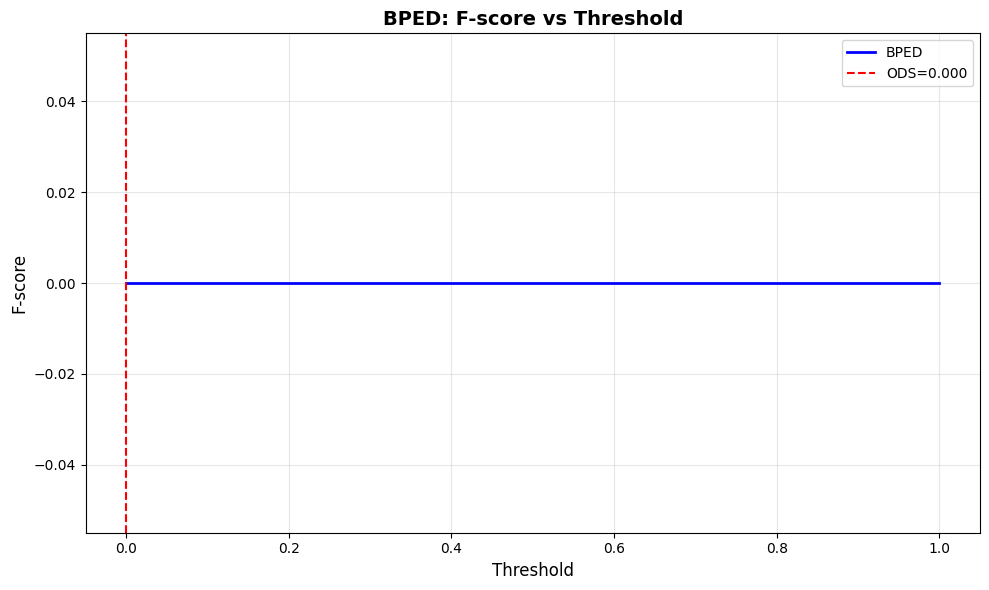

✓ F-score curve saved as bped_fscore_curve.png


In [23]:
# Check if metrics were computed
if 'mean_f_scores' in locals() and 'thresholds' in locals():
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, mean_f_scores, 'b-', linewidth=2, label='BPED')
    plt.axvline(ods_threshold, color='r', linestyle='--', label=f'ODS={ods:.3f}')
    plt.xlabel('Threshold', fontsize=12)
    plt.ylabel('F-score', fontsize=12)
    plt.title('BPED: F-score vs Threshold', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('bped_fscore_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ F-score curve saved as bped_fscore_curve.png")
else:
    print("⚠ Metrics not computed yet. Please run the metrics computation cell first.")

## 8. Save Results

In [24]:
# Save metrics
if 'ods' in locals() and 'ois' in locals() and 'ap' in locals():
    metrics = {
        'model': 'BPED',
        'dataset': DATASET_PATH,
        'num_images': len(results),
        'metrics': {
            'ODS': float(ods),
            'ODS_threshold': float(ods_threshold),
            'OIS': float(ois),
            'AP': float(ap)
        },
        'parameters': model.count_parameters()
    }
    
    with open('bped_metrics.json', 'w') as f:
        json.dump(metrics, f, indent=2)
    
    print("✓ Metrics saved to bped_metrics.json")
    print("\nMetrics:")
    print(json.dumps(metrics, indent=2))
else:
    print("⚠ Metrics not computed yet. Please run the metrics computation cell first.")

✓ Metrics saved to bped_metrics.json

Metrics:
{
  "model": "BPED",
  "dataset": "..\\datasets\\HED_Small",
  "num_images": 32,
  "metrics": {
    "ODS": 0.0,
    "ODS_threshold": 0.0,
    "OIS": 0.0,
    "AP": 0.0
  },
  "parameters": 43737129
}


## 9. Model Architecture Summary

In [25]:
print("BPED Architecture:")
print("="*60)
print("Encoder:")
print("  Stage 1: Oriented Conv (V1-like) + Pyramid Block (64 channels)")
print("  Stage 2: Oriented Conv + Pyramid + Edge Enhancement (128 channels)")
print("  Stage 3: Conv + Pyramid + Edge Enhancement (256 channels)")
print("  Stage 4: Conv + Pyramid (512 channels)")
print("\nDecoder:")
print("  Progressive refinement with skip connections")
print("  Edge predictions at 4 scales (deep supervision)")
print("  Final fusion layer")
print("\nKey Features:")
print("  • Orientation-selective convolutions (4 orientations)")
print("  • Multi-scale pyramid blocks (3x3, 5x5, 7x7)")
print("  • Bio-inspired edge enhancement (center-surround)")
print("  • Attention modulation")
print("  • Deep supervision at multiple scales")
print(f"\nTotal parameters: {model.count_parameters():,}")
print("="*60)

BPED Architecture:
Encoder:
  Stage 1: Oriented Conv (V1-like) + Pyramid Block (64 channels)
  Stage 2: Oriented Conv + Pyramid + Edge Enhancement (128 channels)
  Stage 3: Conv + Pyramid + Edge Enhancement (256 channels)
  Stage 4: Conv + Pyramid (512 channels)

Decoder:
  Progressive refinement with skip connections
  Edge predictions at 4 scales (deep supervision)
  Final fusion layer

Key Features:
  • Orientation-selective convolutions (4 orientations)
  • Multi-scale pyramid blocks (3x3, 5x5, 7x7)
  • Bio-inspired edge enhancement (center-surround)
  • Attention modulation
  • Deep supervision at multiple scales

Total parameters: 43,737,129
